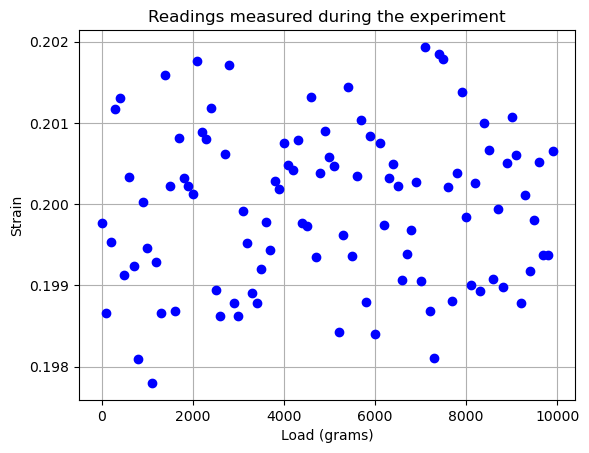

In [24]:
# LS Estimation example
import numpy as np
import matplotlib.pyplot as plt
import math

# Generate Artificial data
number_of_loads = 100
load_gms = np.arange(number_of_loads)*100
offset_error = 2e-1
strains = load_gms*(1e-9) + offset_error

# Generate fake noise (for the sake of simulations
mean = 0
noise_power = 1e-6
std_dev = math.sqrt(noise_power)
measurement_noise = np.random.normal(mean,std_dev,number_of_loads)
strain_readings = strains + measurement_noise 

plt.figure()
plt.plot(load_gms,strain_readings,'bo')
plt.xlabel('Load (grams)')
plt.ylabel('Strain')
plt.title('Readings measured during the experiment')
plt.grid(True)


the solution is a = 2.019526570970446e-08, b = 0.19985386546940975


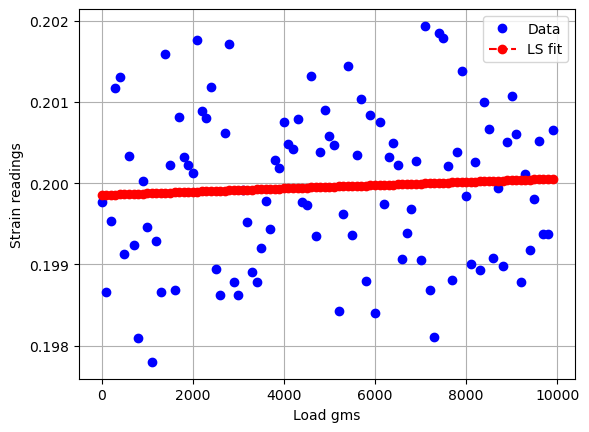

In [25]:
# Now we do LS esitmate
x = load_gms
A = np.column_stack((x, np.ones((number_of_loads,1))))
#A.shape?
A_T_A_inv = np.linalg.inv(np.dot(A.T,A))
ls_mat = np.dot(A_T_A_inv,A.T)
ls_soln = np.dot(ls_mat,strain_readings)
# Print the solution to the screen
print(f'the solution is a = {ls_soln[0]}, b = {ls_soln[1]}')

# Plot it and see
reconstruct_soln = np.dot(A,ls_soln)

fig,ax = plt.subplots()
ax.plot(load_gms,strain_readings,'bo',label='Data')
ax.plot(load_gms,reconstruct_soln,'r--o',label='LS fit')
ax.set_xlabel('Load gms')
ax.set_ylabel('Strain readings')
ax.legend()
ax.grid(True)
plt.show()




the solution forlinear fit isa = 5.317321192522382e-08, b = 0.19969851578762055
the solution forlinear fit isa = 1.1431857568438986e-11, b = -6.000217800235138e-08, c = 0.19988336892450248
the solution forlinear fit isa = -1.638861294990815e-15, b = 3.576894779893758e-11, c = -1.558935912328771e-07,d = 0.199960485051079


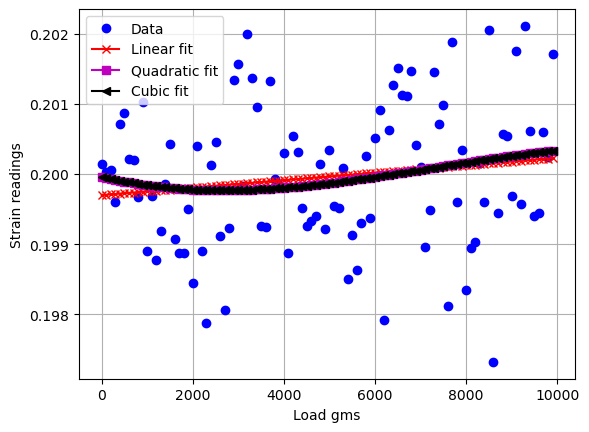

In [22]:
# What if we want to fit a quadratic ? Say we were not sure of the relationship
# between output and input. We then modify the matrix A

x = load_gms

# Forcing a linear fit
A = np.column_stack(( x, np.ones((number_of_loads,1))))
A_T_A_inv = np.linalg.inv(np.dot(A.T,A))
ls_mat = np.dot(A_T_A_inv,A.T)
ls_soln_linear = np.dot(ls_mat,strain_readings)
reconstruct_soln_linear = np.dot(A,ls_soln_linear) # Linear

# Forcing a quadratic fit
A = np.column_stack(( x**2, x, np.ones((number_of_loads,1))))
A_T_A_inv = np.linalg.inv(np.dot(A.T,A))
ls_mat = np.dot(A_T_A_inv,A.T)
ls_soln_quadratic = np.dot(ls_mat,strain_readings)
reconstruct_soln_quad = np.dot(A,ls_soln_quadratic) # Quadratic


# forcing a cubic fit
A = np.column_stack((x**3, x**2, x, np.ones((number_of_loads,1))))
A_T_A_inv = np.linalg.inv(np.dot(A.T,A))
ls_mat = np.dot(A_T_A_inv,A.T)
ls_soln_cubic = np.dot(ls_mat,strain_readings)
reconstruct_soln_cubic = np.dot(A,ls_soln_cubic) # Cubic




# Print the solution to the screen Ls linear
print(
    'the solution for' 
    'linear fit is' 
    f'a = {ls_soln_linear[0]}, b = {ls_soln_linear[1]}')

# Print the solution to the screen Ls quadratic
print(
    'the solution for' 
    'linear fit is' 
    f'a = {ls_soln_quadratic[0]}, b = {ls_soln_quadratic[1]}, c = {ls_soln_quadratic[2]}')


# Print the solution to the screen Ls cubic
print(
    'the solution for' 
    'linear fit is' 
    f'a = {ls_soln_cubic[0]}, b = {ls_soln_cubic[1]}, c = {ls_soln_cubic[2]},d = {ls_soln_cubic[3]}')

fig,ax = plt.subplots()
ax.plot(load_gms,strain_readings,'bo',label='Data')
ax.plot(load_gms,reconstruct_soln_linear,'r-x',label='Linear fit')
ax.plot(load_gms,reconstruct_soln_cubic,'m-s',label='Quadratic fit')
ax.plot(load_gms,reconstruct_soln_cubic,'k-<',label='Cubic fit')
ax.set_xlabel('Load gms')
ax.set_ylabel('Strain readings')
ax.legend()
ax.grid(True)
plt.show()



In [26]:
# Now how good is the LS fit ?
# 1. The r^2 measure which is the ratio of the regression sum of squares/Total sum of squares
# 2. The other is a t-test which uses the ration F = Regression Mean squares (MS)/residual MS

regression_ss =  np.sum((reconstruct_soln_linear  - np.mean(strain_readings))**2)
total_ss = np.sum((strain_readings - np.mean(strain_readings))**2)
residual_ss = total_ss - regression_ss
# 
degrees_of_freeedom = number_of_loads - 2 # For linear fit
residual_dof = degrees_of_freedom
residual_ms = residual_ss/residual_dof
regression_dof = 1 # For linear fit
regression_ms = regression_ss/regression_dof
F = regression_ms/residual_ms



